In [1]:
using Pkg

# Use a fresh local first depot, but keep default depots for stdlib cache access
local_depot = joinpath(homedir(), "AppData", "Local", "JuliaDepotMasterarbeit_v2")
isdir(local_depot) || mkpath(local_depot)

default_depots = copy(DEPOT_PATH)
empty!(DEPOT_PATH)
push!(DEPOT_PATH, local_depot)
append!(DEPOT_PATH, filter(!=(local_depot), default_depots))
ENV["JULIA_DEPOT_PATH"] = join(DEPOT_PATH, ';')
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"

Pkg.activate(".")
Pkg.instantiate()

required_packages = [
    "Statistics", "LinearAlgebra", "LsqFit", "LaTeXStrings", "Plots",
    "DataFrames", "Distributions", "JLD2", "DSP", "Interpolations",
    "Measurements", "NPZ", "Touchstone", "SavitzkyGolay",
    "Rotations", "SpecialPolynomials", "SpecialFunctions", "HDF5",
    "JSON", "Polynomials", "FFTW", "ProgressMeter"
 ]

installed = Set(keys(Pkg.project().dependencies))
missing = [pkg for pkg in required_packages if pkg ∉ installed]
if !isempty(missing)
    Pkg.add(missing)
    Pkg.instantiate()
else
    @info "All required packages are already in this project."
end

  Activating project at `c:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code`
   Resolving package versions...
   Installed ProgressMeter ─ v1.11.0
    Updating `C:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code\Project.toml`
  [92933f4c] + ProgressMeter v1.11.0
    Updating `C:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code\Manifest.toml`
  [92933f4c] + ProgressMeter v1.11.0


In [2]:
using Pkg
Pkg.instantiate()

In [3]:
using Statistics
using LinearAlgebra
using LsqFit
using LaTeXStrings
using Plots
using Plots.Measures
#using StatsPlots
using DataFrames
using Distributions
using ProgressMeter

#using Dates
#using Optim
#using DelimitedFiles
using JLD2
using DSP
using Interpolations
using Measurements
using NPZ
using Touchstone
using SavitzkyGolay
include("MADBead/MADBead.jl");


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [4]:
ϵ_b = 9.23 ± 0.2
Δϵ = (ϵ_b - 1);
r_b = (2.93e-3 ± 15e-6)/2;#Grade 28 
V_b = 4/3*π*r_b^3
α_0 = 3*Δϵ * V_b /(ϵ_b + 2)

P_in = 1
J_0 = 1
r_d = 0.15
A = π*r_d^2
σ_Al = (5.0 ± 1)*1e7

ϵ_d = 9.3 ± 0.1
tanD_d = 1e-5 ± 1e-6
d_d = (1 ± 0.05)*1e-3


0.001 ± 5.0e-5

# Transverse integration (loading ET_results)


In [5]:
et_results = npzread("ET_results.npz")
ν_npz = et_results["frequencies"]

ETs_reduced = et_results["ETs_reduced"]
z_reduced_mm = et_results["z_reduced"]

ETs_full = et_results["ETs_full"]
z_full_mm = et_results["z_full"]

# z arrays in ET_results are in mm -> convert to meters for MADBead model and fitting
z_reduced = z_reduced_mm .* 1e-3
z_full = z_full_mm .* 1e-3

function to_measurement_field(E)
    real.(E) .± 0 .+ 1im*(imag.(E) .± 0)
end

# Normalize ET array shape to (ν, z), regardless of source axis order
function as_freq_by_z(E, ν, z; name="E")
    s1, s2 = size(E)
    if s1 == length(ν) && s2 == length(z)
        return E
    elseif s2 == length(ν) && s1 == length(z)
        return permutedims(E)
    else
        error("$(name) has incompatible shape $(size(E)); expected (ν,z)=($(length(ν)),$(length(z))) or (z,ν)=($(length(z)),$(length(ν))).")
    end
end

ETs_reduced_νz = as_freq_by_z(ETs_reduced, ν_npz, z_reduced; name="ETs_reduced")
ETs_full_νz    = as_freq_by_z(ETs_full, ν_npz, z_full; name="ETs_full")

∫dA_E_reduced = to_measurement_field(ETs_reduced_νz)
∫dA_E_full    = to_measurement_field(ETs_full_νz)

# Shape checks: axis 1 = frequency, axis 2 = z
@assert size(∫dA_E_reduced, 1) == length(ν_npz)
@assert size(∫dA_E_reduced, 2) == length(z_reduced)
@assert size(∫dA_E_full, 1) == length(ν_npz)
@assert size(∫dA_E_full, 2) == length(z_full)

@info "Loaded transverse E-field from ET_results.npz" reduced_size=size(∫dA_E_reduced) full_size=size(∫dA_E_full) z_units_input="mm" z_units_internal="m"


┌ Info: Loaded transverse E-field from ET_results.npz
│   reduced_size = (1001, 4)
│   full_size = (1001, 17)
│   z_units_input = mm
│   z_units_internal = m
└ @ Main c:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:42


In [6]:
z_reduced

4-element Vector{Float64}:
 0.002
 0.035
 0.022
 0.016

In [7]:
z_full

17-element Vector{Float64}:
 0.002
 0.003
 0.004
 0.035
 0.036000000000000004
 0.037
 0.038
 0.039
 0.04
 0.041
 0.042
 0.022
 0.023
 0.024
 0.016
 0.017
 0.018000000000000002

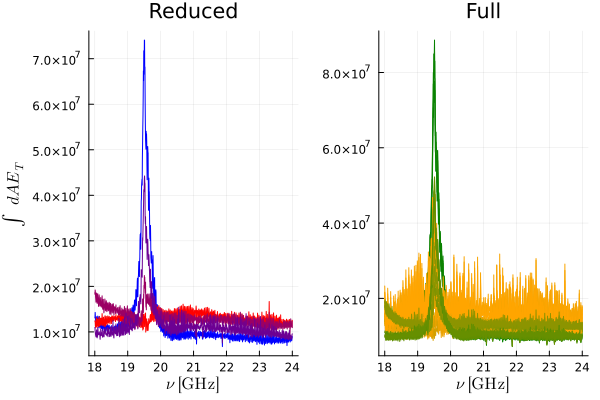

In [8]:
plot(layout=(1,2))

c_reduced = cgrad([:blue,:red])[(z_reduced .- minimum(z_reduced)) ./ (maximum(z_reduced)-minimum(z_reduced))]
plot!(sp=1, ν_npz*1e-9, getfield.(abs.(∫dA_E_reduced),:val), c=c_reduced', label="", title="Reduced")
plot!(sp=1, xlabel=L"\nu \ \mathrm{[GHz]}", ylabel=L"\int dA E_T")

c_full = cgrad([:green,:orange])[(z_full .- minimum(z_full)) ./ (maximum(z_full)-minimum(z_full))]
plot!(sp=2, ν_npz*1e-9, getfield.(abs.(∫dA_E_full),:val), c=c_full', label="", title="Full")
plot!(sp=2, xlabel=L"\nu \ \mathrm{[GHz]}")
plot!()


In [9]:
δ_e_mie = [MADBead.calc_δ_e_mie(ϵ_b,r_b;f=f) for f in ν_npz];
δ_c_mie = [MADBead.calc_δ_c_mie(ϵ_b,r_b;f=f) for f in ν_npz];

In [10]:
# Mirror position fixed at -2 mm in original coordinate system
z_m_original_val = -2e-3
z_m_original = z_m_original_val ± 0

# Shift full coordinate system by +2 mm so mirror is at z=0
z_shift = -z_m_original_val
z_m_FM504_M = 0.0 ± 0

# ET z-grids are treated as mirror-distance coordinates (positive away from mirror).
# Convert to original global coordinates, then apply +2 mm shift.
# z_abs = z_m_original - z_distance ; z_shifted = z_abs + 2 mm
z_reduced_fit = Float64.(z_m_original_val .- z_reduced .+ z_shift)
z_full_fit = Float64.(z_m_original_val .- z_full .+ z_shift)

@info "Applied global z-shift and coordinate conversion" z_shift_m=z_shift z_shift_mm=z_shift*1e3 z_m_original_m=z_m_original z_m_shifted_m=z_m_FM504_M reduced_fit_range_mm=(minimum(z_reduced_fit)*1e3, maximum(z_reduced_fit)*1e3) full_fit_range_mm=(minimum(z_full_fit)*1e3, maximum(z_full_fit)*1e3)

┌ Info: Applied global z-shift and coordinate conversion
│   z_shift_m = 0.002
│   z_shift_mm = 2.0
│   z_m_original_m = -0.002 ± 0.0
│   z_m_shifted_m = 0.0 ± 0.0
│   reduced_fit_range_mm = (-35.0, -2.0)
│   full_fit_range_mm = (-42.0, -2.0)
└ @ Main c:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:15


In [11]:
#n_disk = length(z_region)-1 ± 0 
n_disk = 3 ± 0
E0_0 = 1 ± 1
z_m_0 = z_m_FM504_M

σ_m_0 = σ_Al

d_v_i = [8.265 ± 0.1,9.813 ± 0.1,9.813 ± 0.1]*1e-3 

p0_all = Dict("E_0"=>E0_0,"z_m"=>z_m_0,"σ_m"=>σ_m_0,"n_disk"=>n_disk)
for i in 1:Int(n_disk.val)
    p0_all["d_v_$i"]=d_v_i[i]
    p0_all["d_d_$i"]=d_d
    p0_all["ϵ_d_$i"]=ϵ_d
    p0_all["tanD_d_$i"]=tanD_d
end
p0_all["r_b"]=r_b
p0_all["ϵ_b"]=ϵ_b


keys_optim = ["E_0","d_v_1","d_v_2","d_v_3"];
keys_helper = ["n_disk"]
keys_fixed = [setdiff(keys(p0_all),keys_optim,keys_helper)...];
keys_all = [keys_optim...,keys_helper...,keys_fixed...];

In [12]:
quick_mode = true              # true: fast debug run, false: full run
quick_labels = ["reduced", "full"]     # datasets to run in quick mode

N_mc = quick_mode ? 30 : 100
idx_sub_test = 1:length(ν_npz)

function fit_boostfactor(z_positions, int_dA_E; label)
    @info "Starting fit" label=label N_mc=N_mc n_freq=length(idx_sub_test) n_z=length(z_positions) nthreads=Threads.nthreads()
    res = Dict{Symbol,Any}()
    res[:label] = label
    res[:z_positions] = z_positions
    res[:int_dA_E] = int_dA_E

    p_all_ν_mc = MADBead.fit_E_z_MC(ν_npz[idx_sub_test], z_positions, int_dA_E[idx_sub_test,:],
                                    p0_all, keys_optim, keys_fixed, keys_helper, N_mc);
    res[:p_all_ν_mc] = p_all_ν_mc

    p_final_ν = DataFrame("f"=>ν_npz);
    [p_final_ν[!,key].= (mean.(p_all_ν_mc[!,key]).±std.(p_all_ν_mc[!,key])) for key in keys(p0_all)];
    res[:p_final_ν] = p_final_ν

    int_dz_E_mc = zeros(Complex{Float64},length(ν_npz),N_mc);
    prog_int = Progress(length(ν_npz); desc="[$label] int_dz_E (threaded)", dt=0.3)
    Threads.@threads for f in 1:length(ν_npz)
        for i in 1:N_mc
            p_dict = Dict(key=>p_all_ν_mc[f,key][i] for key in keys(p0_all))
            int_dz_E_mc[f,i] = MADBead.int_dz_E_param(p_dict;f=ν_npz[f])
        end
        next!(prog_int)
    end
    res[:int_dz_E_mc] = int_dz_E_mc

    int_dV_E = mean(abs.(int_dz_E_mc),dims=2)[:] .± std(abs.(int_dz_E_mc),dims=2)[:];
    res[:int_dV_E] = int_dV_E

    P_sig = J_0^2/(16*P_in)*abs2.(int_dV_E)
    P_0 = MADBead.c_const*A*J_0^2 ./ (2*MADBead.ϵ0*(2pi*ν_npz).^2)
    res[:boostfactor] = P_sig ./ P_0 

    @info "Finished fit" label=label
    return res
end

labels_to_run = quick_mode ? quick_labels : ["reduced", "full"]
bf_results = Dict{String,Any}()
prog_label = Progress(length(labels_to_run); desc="Dataset fits", dt=0.2)
for label in labels_to_run
    if label == "reduced"
        bf_results[label] = fit_boostfactor(z_reduced_fit, ∫dA_E_reduced; label="reduced")
    elseif label == "full"
        bf_results[label] = fit_boostfactor(z_full_fit, ∫dA_E_full; label="full")
    else
        @warn "Unknown label in labels_to_run; skipping." label=label
    end
    next!(prog_label)
end


┌ Info: Starting fit
│   label = reduced
│   N_mc = 30
│   n_freq = 1001
│   n_z = 4
│   nthreads = 1
└ @ Main c:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:8
[reduced] int_dz_E (threaded) 100%|██████████████████████| Time: 0:00:08
┌ Info: Finished fit
│   label = reduced
└ @ Main c:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:40
┌ Info: Starting fit
│   label = full
│   N_mc = 30
│   n_freq = 1001
│   n_z = 17
│   nthreads = 1
└ @ Main c:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:8
[full] int_dz_E (threaded) 100%|█████████████████████████| Time: 0:00:00
┌ Info: Finished fit
│   label = full
└ @ Main c:\Users\nabil\OneDrive\Dokumente\Uni\Module\4. MS\Masterarbeit\code\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZm

In [ ]:
# Post-corrections (Finite Domain + RC mismatch), analogous to 5_Analysis_Boostfactor_Determination_3Disks
ν = ν_npz

# ---------- Finite Domain correction ----------
fid_fd_default = joinpath("..", "dark-photon-analysis-main", "Analysis_Results_Temporary", "3_result_FD_correction_FM504_A_temp.jld2")
η_fd = nothing
if isfile(fid_fd_default)
    data_FM504_A = jldopen(fid_fd_default)
    ν_A = data_FM504_A["ν"]
    η_fd_A = data_FM504_A["η_fd"]
    close(data_FM504_A)
    η_fd = MADBead.interpolate_measurement(ν_A, η_fd_A, ν, extrapolate=true)
    @info "Loaded finite-domain correction" path=fid_fd_default
else
    @warn "Finite-domain correction file not found. Set fid_fd_default to your local file to enable this correction." path=fid_fd_default
end

for label in keys(bf_results)
    res = bf_results[label]
    res[:boostfactor_fd] = isnothing(η_fd) ? missing : (res[:boostfactor] ./ abs2.(η_fd))
end

# ---------- RC mismatch correction ----------
# Requires measured reflection Γ on the same ν grid.
# If Γ is not defined in this notebook, the correction is skipped.
path_to_science_data = joinpath("..", "dark-photon-analysis-main", "..", "Data", "Measurements", "SHELL Data Sync", "2023_12 Dark Photon Data")
fid_RC = joinpath(path_to_science_data, "VNA", "lna_20240207.s1p")

Γ_RC_interp = nothing
if isfile(fid_RC)
    data_RC = parse_touchstone_file(fid_RC)
    ν_RC = Touchstone.freqs(data_RC)
    Γ_RC = Touchstone.reals(data_RC) .+ 1im*Touchstone.imags(data_RC)
    Γ_RC_sg = savitzky_golay(real.(Γ_RC), 71, 4).y .+ 1im*savitzky_golay(imag.(Γ_RC), 71, 4).y
    Γ_RC_interp = LinearInterpolation(ν_RC, Γ_RC_sg).(ν)
    @info "Loaded RC reflection data" path=fid_RC
else
    @warn "RC touchstone file not found. Set fid_RC/path_to_science_data to your local measurement path to enable RC correction." path=fid_RC
end

if @isdefined(Γ) && !isnothing(Γ_RC_interp)
    L0 = (53.423e-12) * MADBead.c_const
    ΔL_err = 0.006e-12 * MADBead.c_const
    N_mc_RC = 400

    F_RC_MC = zeros(length(ν), N_mc_RC)
    for i in 1:N_mc_RC
        L = ΔL_err * randn() + L0
        F = (1 .- abs2.(Γ_RC_interp .* exp.(-2im * 2π * ν / MADBead.c_const * L))) ./
            abs2.(1 .- Γ_RC_interp .* Γ .* exp.(-2im * 2π * ν / MADBead.c_const * L))
        F_RC_MC[:, i] = F
    end
    F_RC = mean(F_RC_MC, dims=2)[:] .± std(F_RC_MC, dims=2)[:]

    for label in keys(bf_results)
        res = bf_results[label]
        res[:F_RC] = F_RC
        if !ismissing(res[:boostfactor_fd])
            res[:boostfactor_fd_rc] = res[:boostfactor_fd] .* F_RC
        else
            res[:boostfactor_fd_rc] = missing
        end
    end

    @info "Applied RC mismatch correction to all boostfactor results."
else
    @warn "Skipping RC mismatch correction because Γ is not defined in this notebook or RC data is unavailable."
    for label in keys(bf_results)
        res = bf_results[label]
        res[:boostfactor_fd_rc] = missing
    end
end

# Quick comparison plot per dataset
for label in keys(bf_results)
    res = bf_results[label]
    p = plot()
    plot!(p, ν .* 1e-9, getfield.(res[:boostfactor], :val), ribbon=getfield.(res[:boostfactor], :err), lw=1.5, label="raw")

    if !ismissing(res[:boostfactor_fd])
        plot!(p, ν .* 1e-9, getfield.(res[:boostfactor_fd], :val), ribbon=getfield.(res[:boostfactor_fd], :err), lw=1.5, label="w/ finite-domain")
    end

    if !ismissing(res[:boostfactor_fd_rc])
        plot!(p, ν .* 1e-9, getfield.(res[:boostfactor_fd_rc], :val), ribbon=getfield.(res[:boostfactor_fd_rc], :err), lw=1.5, label="w/ finite-domain + RC")
    end

    plot!(p, xlabel=L"\nu \ \mathrm{[GHz]}", ylabel=L"\beta^2", title="$(uppercasefirst(label)) boostfactor corrections")
    display(p)
end

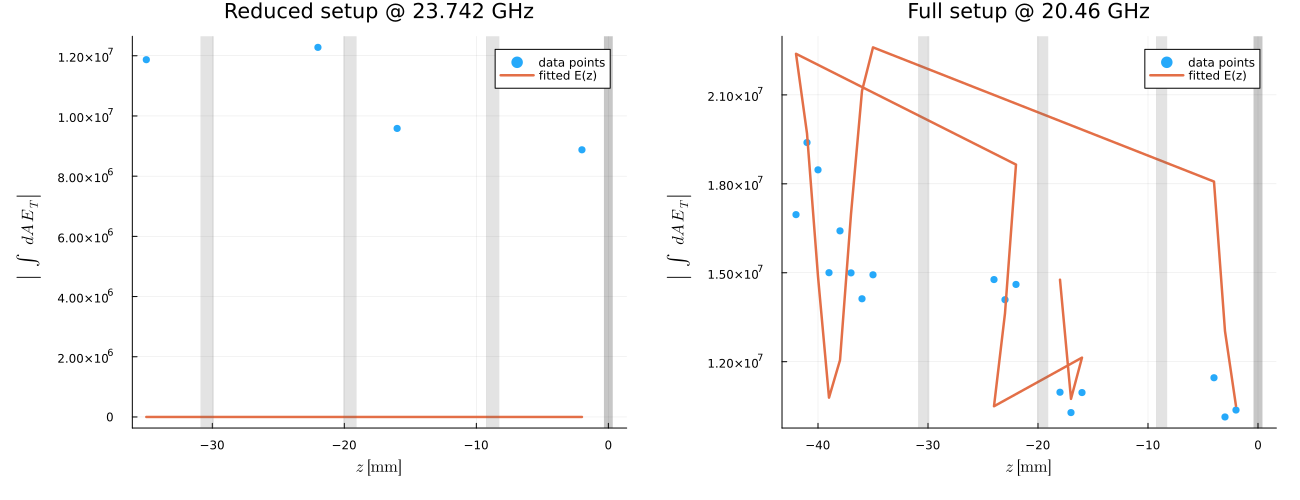

In [13]:
function fitted_Eabs_vs_z(z_positions, int_dA_E, p_final_ν, f_idx)
    f_val = ν_npz[f_idx]

    p_fit = Dict{String,Float64}()
    for key in keys(p0_all)
        p_fit[key] = Float64(getfield(p_final_ν[f_idx, key], :val))
    end

    δ = MADBead.calc_δ_e_mie(p_fit["ϵ_b"], p_fit["r_b"]; f=f_val)
    δc = MADBead.calc_δ_c_mie(p_fit["ϵ_b"], p_fit["r_b"]; f=f_val)

    E_fit = sqrt.(abs.(MADBead.E_field2_conv_1D_z_param(z_positions, p_fit; f=f_val, δ=δ, δc=δc)))
    E_data = getfield.(abs.(int_dA_E[f_idx, :]), :val)
    @assert length(E_data) == length(z_positions) "E_data and z_positions length mismatch"

    return f_val, E_fit, E_data
end

function fixed_geometry_ranges_mm()
    z_m_mm = getfield(z_m_FM504_M, :val) * 1e3
    d_disk_mm = getfield(d_d, :val) * 1e3

    # Build disks from surface-to-surface spacings d_v_i and disk thickness d_d
    # Mirror at z_m_mm (surface). Moving away from mirror is toward smaller z.
    disk_ranges_mm = Tuple{Float64,Float64}[]
    surface_mm = z_m_mm
    for dv in d_v_i
        gap_mm = getfield(dv, :val) * 1e3
        z_near_mm = surface_mm - gap_mm
        z_far_mm = z_near_mm - d_disk_mm
        push!(disk_ranges_mm, (z_far_mm, z_near_mm))
        surface_mm = z_far_mm
    end

    return z_m_mm, disk_ranges_mm
end

function plot_fit_vs_data(label; f_idx=nothing)
    res = bf_results[label]
    z_positions = res[:z_positions]
    int_dA_E = res[:int_dA_E]
    p_final_ν = res[:p_final_ν]

    if isnothing(f_idx)
        f_idx = argmax(getfield.(res[:boostfactor], :val))
    end

    f_val, E_fit, E_data = fitted_Eabs_vs_z(z_positions, int_dA_E, p_final_ν, f_idx)

    z_mm = z_positions .* 1e3
    plt = scatter(z_mm, E_data;
                  label="data points",
                  markersize=4,
                  markerstrokewidth=0,
                  alpha=0.85)
    plot!(plt, z_mm, E_fit;
          label="fitted E(z)",
          lw=2.5)

    z_m_mm, disk_ranges_mm = fixed_geometry_ranges_mm()
    z_span_mm = maximum(z_mm) - minimum(z_mm)
    mirror_half_width_mm = max(0.15, 0.01 * z_span_mm)

    for (z_l, z_r) in disk_ranges_mm
        vspan!(plt, [z_l, z_r]; color=:gray40, alpha=0.18, label="")
    end
    vspan!(plt, [z_m_mm - mirror_half_width_mm, z_m_mm + mirror_half_width_mm];
           color=:black, alpha=0.22, label="")

    plot!(plt;
          xlabel=L"z\ \mathrm{[mm]}",
          ylabel=L"\left|\int dA\,E_T\right|",
          title="$(uppercasefirst(label)) setup @ $(round(f_val * 1e-9, digits=3)) GHz",
          left_margin=10mm,
          right_margin=4mm,
          top_margin=4mm,
          bottom_margin=10mm)

    return plt
end

plot(
    plot_fit_vs_data("reduced"),
    plot_fit_vs_data("full"),
    layout=(1, 2),
    size=(1300, 500),
    margin=2mm
)

In [20]:
z_reduced

4-element Vector{Float64}:
 0.002
 0.035
 0.022
 0.016

In [15]:
for label in ["reduced", "full"]
    res = bf_results[label]
    e0_vals = getfield.(res[:p_final_ν][!, "E_0"], :val)
    println("\n--- ", label, " ---")
    println("E_0 min/max = ", minimum(e0_vals), " / ", maximum(e0_vals))
    f_idx = argmax(getfield.(res[:boostfactor], :val))
    f_val, E_fit, E_data = fitted_Eabs_vs_z(res[:z_positions], res[:int_dA_E], res[:p_final_ν], f_idx)
    println("f_idx = ", f_idx, ", f = ", f_val*1e-9, " GHz")
    println("E_data min/max = ", minimum(E_data), " / ", maximum(E_data))
    println("E_fit  min/max = ", minimum(E_fit),  " / ", maximum(E_fit))
    println("first E_data = ", E_data[1:min(end,5)])
    println("first E_fit  = ", E_fit[1:min(end,5)])
end


--- reduced ---
E_0 min/max = 1.2004144505340053 / 1.2004144505340053
f_idx = 968, f = 23.802000000000003 GHz
E_data min/max = 7.690354191421185e6 / 1.1115686047681306e7
E_fit  min/max = 0.0 / 0.0
first E_data = [7.690354191421185e6, 1.1115686047681306e7, 1.0889845953521434e7, 8.332726405218313e6]
first E_fit  = [0.0, 0.0, 0.0, 0.0]

--- full ---
E_0 min/max = 5.2729131765039405e6 / 2.0368053188412014e7
f_idx = 884, f = 23.298000000000002 GHz
E_data min/max = 1.1974367678695759e7 / 2.2147872380826537e7
E_fit  min/max = 0.0 / 0.0
first E_data = [1.2760809434073417e7, 1.2660495443072014e7, 1.4512873680433255e7, 1.7597729575972278e7, 1.433131814814528e7]
first E_fit  = [0.0, 0.0, 0.0, 0.0, 0.0]


In [16]:
label = "reduced"
res = bf_results[label]
f_idx = argmax(getfield.(res[:boostfactor], :val))
f_val = ν_npz[f_idx]
p_final_ν = res[:p_final_ν]
z_positions = res[:z_positions]

p_fit = Dict{String,Float64}()
for key in keys(p0_all)
    p_fit[key] = Float64(getfield(p_final_ν[f_idx, key], :val))
end

println("f = ", f_val*1e-9, " GHz")
for k in sort(collect(keys(p_fit)))
    println(k, " => ", p_fit[k])
end

distance, epsilon, E_in = MADBead.fit_param_to_model(p_fit; f=f_val)
println("distance = ", distance)
println("sum(distance[2:end]) = ", sum(distance[2:end]))
println("z_positions = ", z_positions)
println("E_in = ", E_in)

δ = MADBead.calc_δ_e_mie(p_fit["ϵ_b"], p_fit["r_b"]; f=f_val)
δc = MADBead.calc_δ_c_mie(p_fit["ϵ_b"], p_fit["r_b"]; f=f_val)
E2 = MADBead.E_field2_conv_1D_z_param(z_positions, p_fit; f=f_val, δ=δ, δc=δc)
println("E2 = ", E2)
println("abs(E2) = ", abs.(E2))
println("E_fit = ", sqrt.(abs.(E2)))

f = 23.802000000000003 GHz
E_0 => 1.2004144505340053
d_d_1 => 0.0009999303757119698
d_d_2 => 0.0009954944423157647
d_d_3 => 0.0009962248448568223
d_v_1 => 0.008250183568693887
d_v_2 => 0.009791598941504016
d_v_3 => 0.009819622532677166
n_disk => 3.0
r_b => 0.001465559544239266
tanD_d_1 => 1.0084488555364543e-5
tanD_d_2 => 1.0078777181186684e-5
tanD_d_3 => 1.0033181754583943e-5
z_m => -0.002
σ_m => 4.9068379769235045e7
ϵ_b => 9.25232490544993
ϵ_d_1 => 9.286885562456987
ϵ_d_2 => 9.307256368336239
ϵ_d_3 => 9.294649121232238
distance = [0.0, 0.008250183568693887, 0.0009999303757119698, 0.009791598941504016, 0.0009954944423157647, 0.009819622532677166, 0.0009962248448568223, -0.032853054705759624, 0.0]
sum(distance[2:end]) = -0.0019999999999999983
z_positions = [0.002, 0.035, 0.022, 0.016]
E_in = 1.2004144505340053 + 0.0im
E2 = ComplexF64[0.0 - 0.0im, 0.0 + 0.0im, 0.0 - 0.0im, 0.0 - 0.0im]
abs(E2) = [0.0, 0.0, 0.0, 0.0]
E_fit = [0.0, 0.0, 0.0, 0.0]


In [ ]:
# Quick sanity check: model response should be non-zero on shifted z-grid
p_test = Dict(key => Float64(getfield(p0_all[key], :val)) for key in keys(p0_all))
f_test = ν_npz[argmax(getfield.(abs.(∫dA_E_reduced[:, 1]), :val))]
δ_test = MADBead.calc_δ_e_mie(p_test["ϵ_b"], p_test["r_b"]; f=f_test)
δc_test = MADBead.calc_δ_c_mie(p_test["ϵ_b"], p_test["r_b"]; f=f_test)
E2_test = MADBead.E_field2_conv_1D_z_param(z_reduced_fit, p_test; f=f_test, δ=δ_test, δc=δc_test)
println("sanity abs(E2) min/max on z_reduced_fit = ", minimum(abs.(E2_test)), " / ", maximum(abs.(E2_test)))